**Importing Libararies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, log_loss

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("/content/loan_approval_dataset.csv")

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**Columns cleaning**

In [30]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**Data set checking**

In [31]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nLoan status counts:")
print(df["loan_status"].value_counts())

Dataset shape: (4269, 13)

Column names:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

Data types:
loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

Missing values:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount               

**Possible Negative/Outliers**

In [32]:
print("Negative values in residential_assets_value:")
print(df[df["residential_assets_value"] < 0])

Negative values in residential_assets_value:
      loan_id  no_of_dependents     education self_employed  income_annum  \
59         60                 4  Not Graduate           Yes       5500000   
196       197                 4  Not Graduate           Yes        400000   
559       560                 2      Graduate           Yes        200000   
702       703                 4      Graduate           Yes       6300000   
737       738                 2      Graduate           Yes        900000   
784       785                 0      Graduate            No       5000000   
904       905                 2      Graduate            No       4100000   
1089     1090                 3      Graduate            No       5100000   
1163     1164                 2      Graduate            No       4500000   
1350     1351                 5      Graduate            No       4000000   
1392     1393                 0      Graduate           Yes        400000   
1773     1774                 2

**Loan Status distribution**

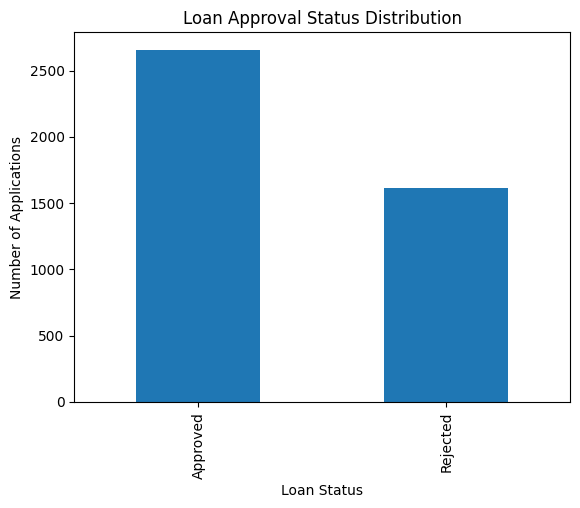

In [8]:
df["loan_status"].value_counts().plot(kind="bar")
plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

**CIBIL Score distribution**

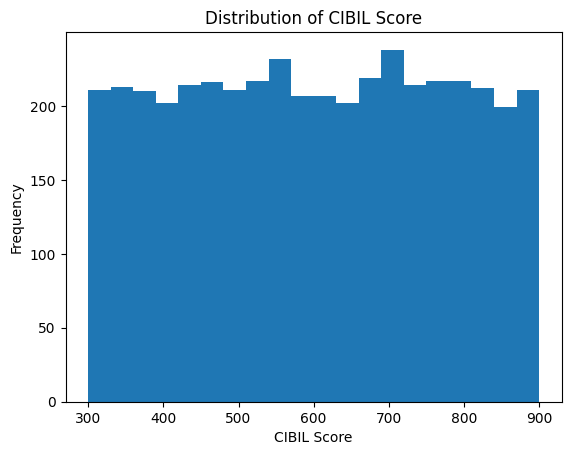

In [9]:
df["cibil_score"].plot(kind="hist", bins=20)
plt.title("Distribution of CIBIL Score")
plt.xlabel("CIBIL Score")
plt.ylabel("Frequency")
plt.show()

**Income vs Loan Amount**

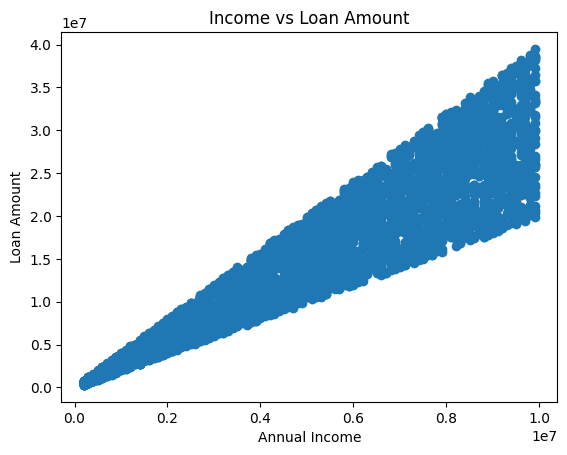

In [10]:
plt.scatter(df["income_annum"], df["loan_amount"])
plt.title("Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

**Average CIBIL score by loan status**

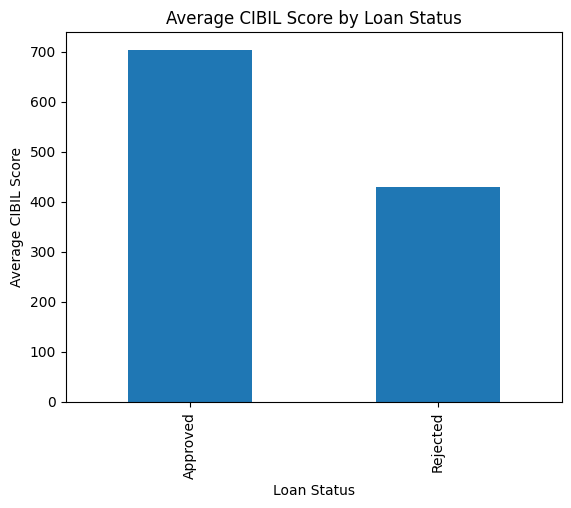

In [11]:
df.groupby("loan_status")["cibil_score"].mean().plot(kind="bar")
plt.title("Average CIBIL Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average CIBIL Score")
plt.show()

**Encode categorical columns**

In [12]:
data = df.copy()

data["education"] = data["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

data["self_employed"] = data["self_employed"].map({
    "Yes": 1,
    "No": 0
})

data["loan_status"] = data["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [13]:
X = data.drop(["loan_id", "loan_status"], axis=1)
y = data["loan_status"]

print(X.head())
print(y.head())

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          1              0       9600000     29900000   
1                 0          0              1       4100000     12200000   
2                 3          1              0       9100000     29700000   
3                 3          1              0       8200000     30700000   
4                 5          0              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0             22700

**Train-test split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


**Scaledata for SVM**

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train SVM Model**

In [16]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(C=1, probability=True, random_state=42)

**Evaluate SVM**

In [17]:
svm_predictions = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))

print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

SVM Accuracy: 0.9449648711943794

Confusion Matrix:
[[301  22]
 [ 25 506]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       323
           1       0.96      0.95      0.96       531

    accuracy                           0.94       854
   macro avg       0.94      0.94      0.94       854
weighted avg       0.95      0.94      0.95       854



   **SVM confusion matrix graph**

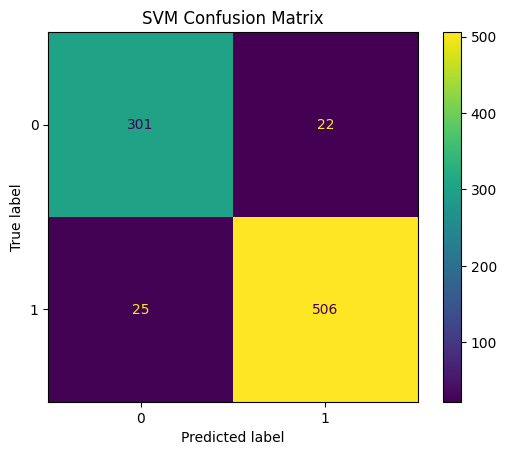

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_predictions)
plt.title("SVM Confusion Matrix")
plt.show()

**3D SVM Visualization**

In [19]:
pca = PCA(n_components=3, random_state=42)

X_scaled_all = StandardScaler().fit_transform(X)
X_pca = pca.fit_transform(X_scaled_all)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_3d = SVC(kernel="linear", C=1, random_state=42)
svm_3d.fit(X_pca_train, y_pca_train)

print("3D PCA SVM Accuracy:", accuracy_score(y_pca_test, svm_3d.predict(X_pca_test)))

3D PCA SVM Accuracy: 0.6615925058548009


**3D Decision Boundary Graph**

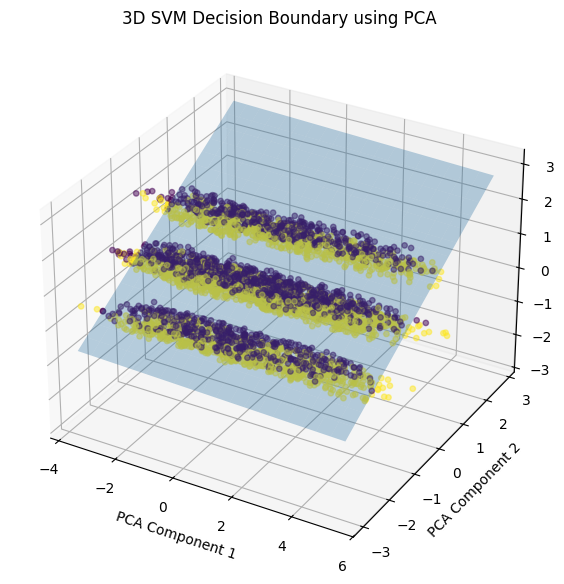

In [20]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=y,
    alpha=0.5,
    s=15
)

xx, yy = np.meshgrid(
    np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 20),
    np.linspace(X_pca[:, 1].min(), X_pca[:, 1].max(), 20)
)

w = svm_3d.coef_[0]
b = svm_3d.intercept_[0]

zz = -(w[0] * xx + w[1] * yy + b) / w[2]

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

plt.title("3D SVM Decision Boundary using PCA")
plt.show()

**Train basic XGBoost model**

In [21]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=1,
              num_parallel_tree=None, ...)

**Evaluate XGBoost**

In [22]:
xgb_predictions = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_predictions))

print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

XGBoost Accuracy: 0.9812646370023419

Confusion Matrix:
[[313  10]
 [  6 525]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



**Confusion Matrix Graph XGBoost**

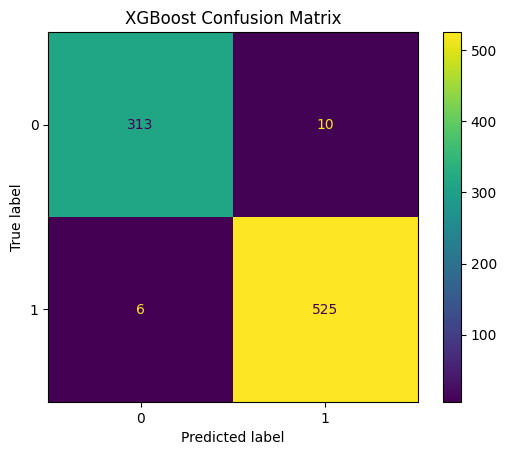

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, xgb_predictions)
plt.title("XGBoost Confusion Matrix")
plt.show()

**Tune XGBoost estimators and learning rate**

In [24]:
results = []

n_estimators_list = [50, 100, 150, 200, 300]
learning_rate_list = [0.01, 0.05, 0.1, 0.2, 0.3]

for n in n_estimators_list:
    for lr in learning_rate_list:

        model = XGBClassifier(
            n_estimators=n,
            learning_rate=lr,
            max_depth=3,
            eval_metric="logloss",
            random_state=42,
            tree_method="hist",
            n_jobs=1
        )

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)

        accuracy = accuracy_score(y_test, predictions)
        prediction_error = 1 - accuracy
        loss = log_loss(y_test, probabilities)

        results.append([n, lr, accuracy, prediction_error, loss])

results_df = pd.DataFrame(
    results,
    columns=["n_estimators", "learning_rate", "accuracy", "prediction_error", "log_loss"]
)

results_df

,n_estimators,learning_rate,accuracy,prediction_error,log_loss
0,50,0.01,0.963700,0.036300,0.366672
1,50,0.05,0.975410,0.024590,0.090440
2,50,0.10,0.975410,0.024590,0.057785
3,50,0.20,0.978923,0.021077,0.049342
4,50,0.30,0.976581,0.023419,0.051449
5,100,0.01,0.963700,0.036300,0.229601
6,100,0.05,0.976581,0.023419,0.057770
7,100,0.10,0.981265,0.018735,0.049287
8,100,0.20,0.980094,0.019906,0.047838
9,100,0.30,0.978923,0.021077,0.052574


**Find best XGBoost results**

In [25]:
best_result = results_df.sort_values(by=["prediction_error", "log_loss"]).head(1)

best_result

,n_estimators,learning_rate,accuracy,prediction_error,log_loss
12,150,0.1,0.983607,0.016393,0.047546


**Train Final best XGBoost Model**

In [33]:
best_n = int(best_result["n_estimators"].values[0])
best_lr = float(best_result["learning_rate"].values[0])

best_xgb_model = XGBClassifier(
    n_estimators=best_n,
    learning_rate=best_lr,
    max_depth=3,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=1
)

best_xgb_model.fit(X_train, y_train)

best_xgb_predictions = best_xgb_model.predict(X_test)

print("Best XGBoost Accuracy:", accuracy_score(y_test, best_xgb_predictions))

print("\nBest XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, best_xgb_predictions))

print("\nBest XGBoost Classification Report:")
print(classification_report(y_test, best_xgb_predictions))

Best XGBoost Accuracy: 0.9836065573770492

Best XGBoost Confusion Matrix:
[[314   9]
 [  5 526]]

Best XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



**Prediction error by number of estimators**

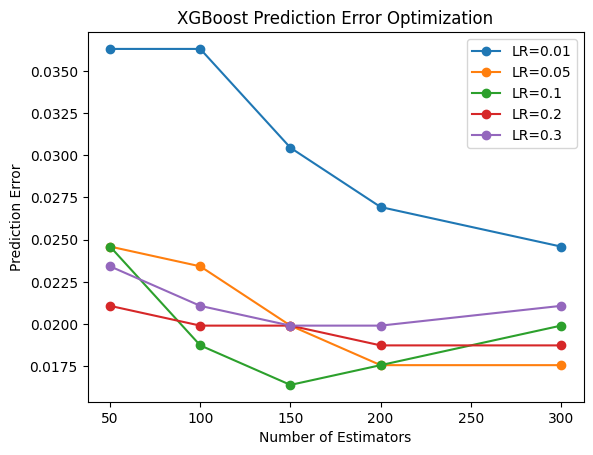

In [26]:
for lr in learning_rate_list:
    temp = results_df[results_df["learning_rate"] == lr]
    plt.plot(temp["n_estimators"], temp["prediction_error"], marker="o", label=f"LR={lr}")

plt.title("XGBoost Prediction Error Optimization")
plt.xlabel("Number of Estimators")
plt.ylabel("Prediction Error")
plt.legend()
plt.show()

**Log loss by number of estimators**

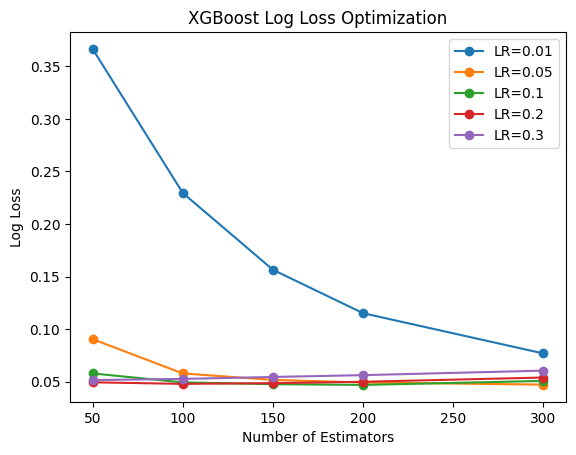

In [27]:
for lr in learning_rate_list:
    temp = results_df[results_df["learning_rate"] == lr]
    plt.plot(temp["n_estimators"], temp["log_loss"], marker="o", label=f"LR={lr}")

plt.title("XGBoost Log Loss Optimization")
plt.xlabel("Number of Estimators")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

**Feature Importance**

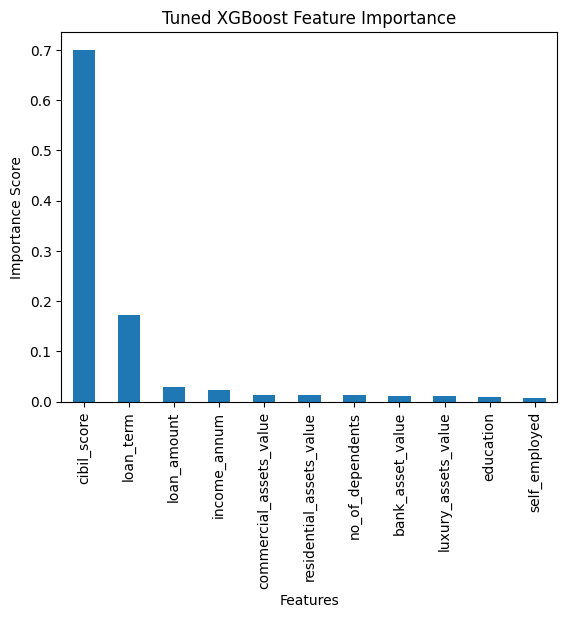

In [34]:
importance = pd.Series(
    best_xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Tuned XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()